In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pices\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Counting the number of occurrences of "Yes" and "No" values in the "Churn" column
df['Churn'].value_counts()
# ~27% customers churn → dataset is imbalanced

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

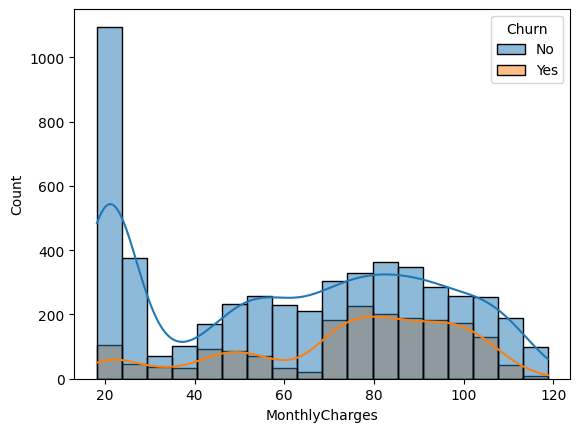

In [6]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)

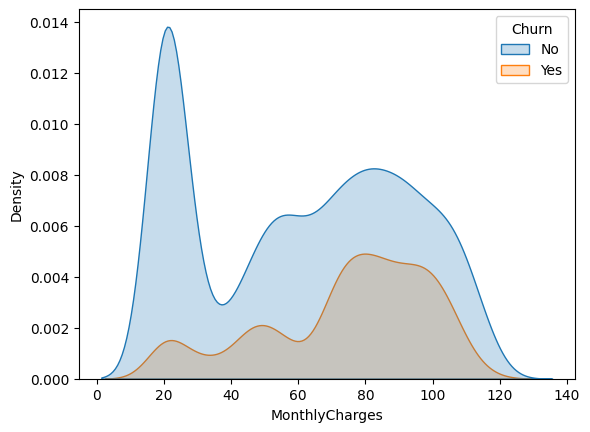

In [7]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.show()

<Axes: xlabel='Contract'>

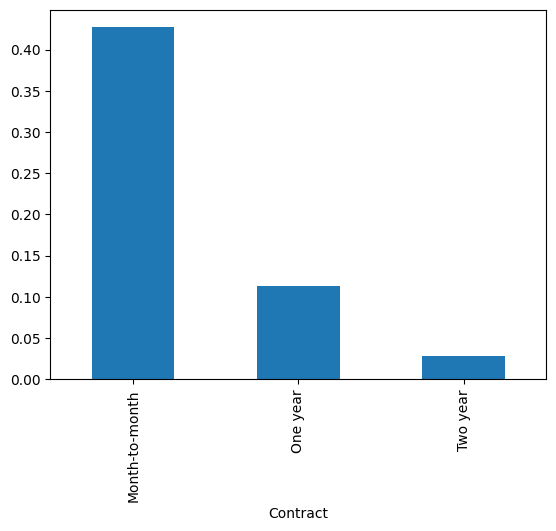

In [8]:
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
churn_rate.plot(kind='bar')

In [9]:
#Converting Churn from Yes/No → 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [10]:
#Features we decide to keep:
features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService']
#Encode only categorical ones
cat_cols=['Contract', 'InternetService']
df_encoded= pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
df_encoded.head()

,tenure,MonthlyCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No
0,1,29.85,False,False,False,False
1,34,56.95,True,False,False,False
2,2,53.85,False,False,False,False
3,45,42.30,True,False,False,False
4,2,70.70,False,False,True,False


In [11]:
#Separate features and target
X=df.drop(['customerID', 'Churn'], axis=1)
y=df['Churn']

In [12]:
#Train-test split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp= train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [13]:
X_val, X_test, y_val, y_test= train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [14]:
#Encoding the categorical features in the train, validation, and test sets using get_dummies with drop_first=True to avoid multicollinearity
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded= pd.get_dummies(X_val, drop_first=True)
X_test_encoded= pd.get_dummies(X_test, drop_first=True)

#Ensuring the validation and test sets have the same columns as the training set to avoid causing any errors, filling any missing columns with 0s
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [15]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_encoded, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_encoded, y_train)
y_pred_rf = rf.predict(X_val_encoded)

In [17]:
from sklearn.metrics import classification_report
y_prob=lr.predict_proba(X_val_encoded)[:,1]
y_pred_lr= (y_prob>=0.4).astype(int)
print("Logistic Regression with custom threshold:\n", classification_report(y_val, y_pred_lr))

Logistic Regression with custom threshold:
               precision    recall  f1-score   support

           0       0.92      0.67      0.77       776
           1       0.48      0.85      0.61       280

    accuracy                           0.71      1056
   macro avg       0.70      0.76      0.69      1056
weighted avg       0.81      0.71      0.73      1056



Logistic Regression - Test Set:
               precision    recall  f1-score   support

           0       0.91      0.69      0.79       776
           1       0.49      0.82      0.61       281

    accuracy                           0.73      1057
   macro avg       0.70      0.76      0.70      1057
weighted avg       0.80      0.73      0.74      1057



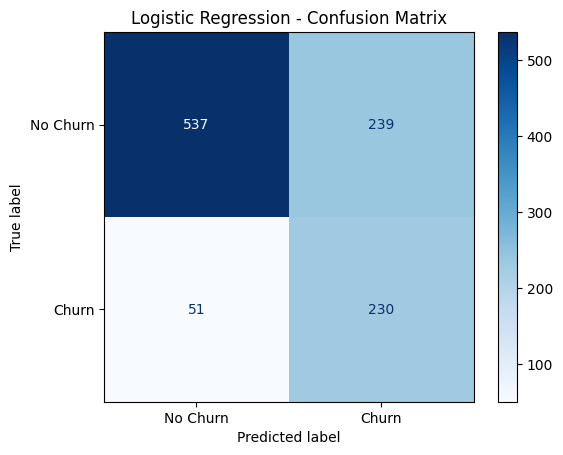

Random Forest - Test Set:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       776
           1       0.65      0.45      0.53       281

    accuracy                           0.79      1057
   macro avg       0.74      0.68      0.70      1057
weighted avg       0.78      0.79      0.78      1057



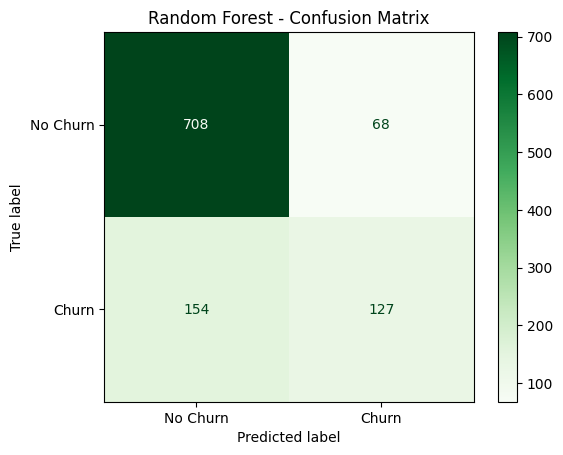

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Encode test labels (already 0/1 so no mapping needed)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0) #we're aligning the test set with the training set columns

# Logistic Regression on test set
y_prob_test = lr.predict_proba(X_test_encoded)[:,1] #we're getting the probabilities for the positive class (churn)
y_pred_test_lr = (y_prob_test >= 0.4).astype(int) #we're applying the same custom threshold of 0.4 to make predictions
print("Logistic Regression - Test Set:\n", classification_report(y_test, y_pred_test_lr)) #we're evaluating the performance of the logistic regression model on the test set using the classification report

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_lr) #we're computing the confusion matrix for the logistic regression model on the test set
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']) #we're creating a confusion matrix display object to visualize the confusion matrix with appropriate labels
disp.plot(cmap='Blues') #we're plotting the confusion matrix using a blue color map for better visualization
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Random Forest on test set
y_pred_test_rf = rf.predict(X_test_encoded) #we're making predictions on the test set using the random forest model
print("Random Forest - Test Set:\n", classification_report(y_test, y_pred_test_rf))

cm_rf = confusion_matrix(y_test, y_pred_test_rf) #we're computing the confusion matrix for the random forest model on the test set
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn']) #we're creating a confusion matrix display object to visualize the confusion matrix for the random forest model with appropriate labels
disp_rf.plot(cmap='Greens') #we're plotting the confusion matrix for the random forest model using a green color map for better visualization
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [19]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance
# it's roughly = number of non-churners / number of churners
# in your data that's roughly 776/281 ≈ 3
# this tells XGBoost to treat churners as 3x more important
# eval_metric='logloss' just suppresses a warning message
xgb = XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss')

xgb.fit(X_train_encoded, y_train)

y_prob_xgb = xgb.predict_proba(X_val_encoded)[:,1]

# Try 0.4 threshold same as others
y_pred_xgb = (y_prob_xgb >= 0.4).astype(int)

print("XGBoost:\n", classification_report(y_val, y_pred_xgb))

XGBoost:
               precision    recall  f1-score   support

           0       0.89      0.73      0.80       776
           1       0.50      0.75      0.60       280

    accuracy                           0.73      1056
   macro avg       0.69      0.74      0.70      1056
weighted avg       0.79      0.73      0.75      1056



In [20]:
# Store recall scores for class 1 (churners) for each model
from sklearn.metrics import recall_score

models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

print(f"{'Model':<25} {'Recall (Churn)':<20} {'Precision (Churn)':<20} {'F1 (Churn)'}")
print("-" * 75)

for name, preds in models.items():
    from sklearn.metrics import precision_score, f1_score
    r = recall_score(y_val, preds)
    p = precision_score(y_val, preds)
    f = f1_score(y_val, preds)
    print(f"{name:<25} {r:<20.2f} {p:<20.2f} {f:.2f}")

Model                     Recall (Churn)       Precision (Churn)    F1 (Churn)
---------------------------------------------------------------------------
Logistic Regression       0.85                 0.48                 0.61
Random Forest             0.53                 0.63                 0.57
XGBoost                   0.75                 0.50                 0.60


In [22]:
from sklearn.model_selection import GridSearchCV

# These are the settings we want to try
param_grid = {
    'C': [0.1, 1, 10],  
    # C controls how strict the model is
    # low C = simpler model, high C = more complex model
    
    'solver': ['liblinear', 'lbfgs']
    # solver is just the math method used to train
    # liblinear is good for small datasets, lbfgs for larger ones
}

# cv=5 means it splits training data into 5 parts and tests each combination
# scoring='recall' means it picks the best settings based on recall
grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000), 
                    param_grid, 
                    cv=5, 
                    scoring='recall')

grid.fit(X_train_encoded, y_train)

# This tells you which combination won
print("Best settings:", grid.best_params_)
print("Best recall:", grid.best_score_)

C:\Users\pices\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\pices\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t

Best settings: {'C': 0.1, 'solver': 'liblinear'}
Best recall: 0.7859378198941241


In [23]:
# grid.best_estimator_ is automatically the best model found above
best_lr = grid.best_estimator_

# Get probabilities on validation set using the tuned model
y_prob_best = best_lr.predict_proba(X_val_encoded)[:,1]
y_pred_best = (y_prob_best >= 0.4).astype(int)

print("Tuned Logistic Regression - Validation Set:\n", 
      classification_report(y_val, y_pred_best))

Tuned Logistic Regression - Validation Set:
               precision    recall  f1-score   support

           0       0.93      0.64      0.76       776
           1       0.46      0.88      0.61       280

    accuracy                           0.70      1056
   macro avg       0.70      0.76      0.68      1056
weighted avg       0.81      0.70      0.72      1056



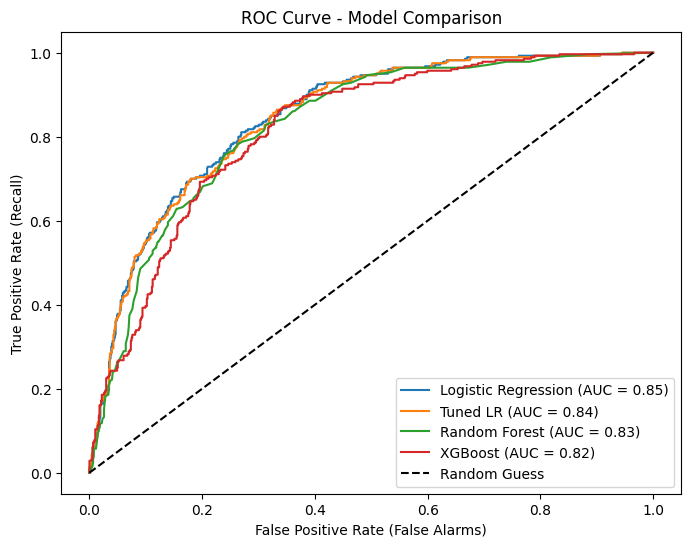

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for all models on validation set
probs = {
    'Logistic Regression': lr.predict_proba(X_val_encoded)[:,1],
    'Tuned LR': best_lr.predict_proba(X_val_encoded)[:,1],
    'Random Forest': rf.predict_proba(X_val_encoded)[:,1],
    'XGBoost': xgb.predict_proba(X_val_encoded)[:,1]
}

plt.figure(figsize=(8,6))

for name, prob in probs.items():
    # fpr = false positive rate (false alarms)
    # tpr = true positive rate (recall)
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    # AUC score = area under the curve, closer to 1.0 is better
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# This diagonal line represents a random guess model
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.show()

FINAL TEST SET RESULTS:

              precision    recall  f1-score   support

           0       0.92      0.66      0.77       776
           1       0.47      0.83      0.60       281

    accuracy                           0.71      1057
   macro avg       0.70      0.75      0.69      1057
weighted avg       0.80      0.71      0.73      1057



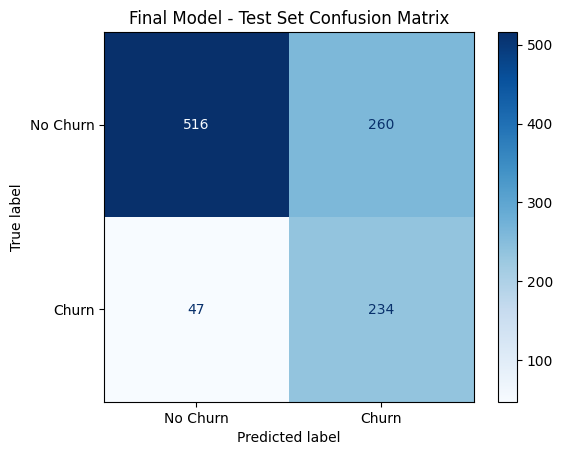

In [25]:
# Final evaluation on test set
threshold = 0.4

y_prob_final = best_lr.predict_proba(X_test_encoded)[:, 1]
y_pred_final = (y_prob_final >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("FINAL TEST SET RESULTS:\n")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                                    display_labels=['No Churn', 'Churn'])

disp_final.plot(cmap='Blues')
plt.title("Final Model - Test Set Confusion Matrix")
plt.show()